# Bank Customer Churn Prediction
Combined notebook: EDA + 4 model comparison (Logistic Regression, Random Forest, XGBoost, Neural Network) on the bank churn dataset (`train.csv`).

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from pathlib import Path
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import tensorflow as tf

from sklearn.metrics import (
    confusion_matrix, accuracy_score, classification_report,
    roc_curve, auc, f1_score
)
import joblib

c:\Program Files\Python312\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


## 2. Load Data

In [2]:
data = Path("Machine learning Models/Neural_Networks/train.csv")
df = pd.read_csv(data)
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0


In [3]:
df.shape

(165034, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165034 entries, 0 to 165033
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               165034 non-null  int64  
 1   CustomerId       165034 non-null  int64  
 2   Surname          165034 non-null  object 
 3   CreditScore      165034 non-null  int64  
 4   Geography        165034 non-null  object 
 5   Gender           165034 non-null  object 
 6   Age              165034 non-null  float64
 7   Tenure           165034 non-null  int64  
 8   Balance          165034 non-null  float64
 9   NumOfProducts    165034 non-null  int64  
 10  HasCrCard        165034 non-null  float64
 11  IsActiveMember   165034 non-null  float64
 12  EstimatedSalary  165034 non-null  float64
 13  Exited           165034 non-null  int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 17.6+ MB


In [5]:
df.isnull().sum()

id                 0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

## 3. Exploratory Data Analysis

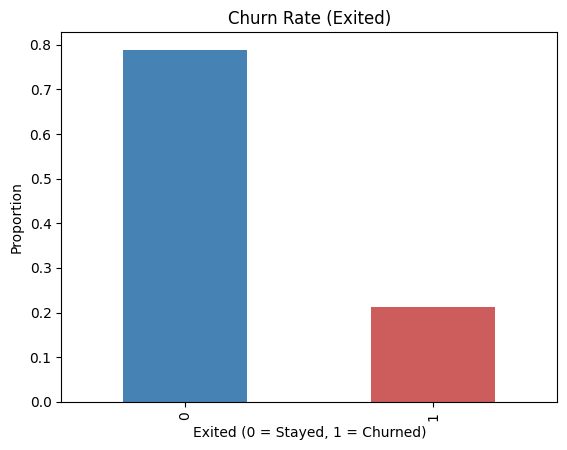

Exited
0    0.788401
1    0.211599
Name: proportion, dtype: float64


In [6]:
# Target variable distribution
df['Exited'].value_counts(normalize=True).plot(
    kind='bar', color=['steelblue','indianred'], title='Churn Rate (Exited)'
)
plt.xlabel('Exited (0 = Stayed, 1 = Churned)')
plt.ylabel('Proportion')
plt.show()

print(df['Exited'].value_counts(normalize=True))

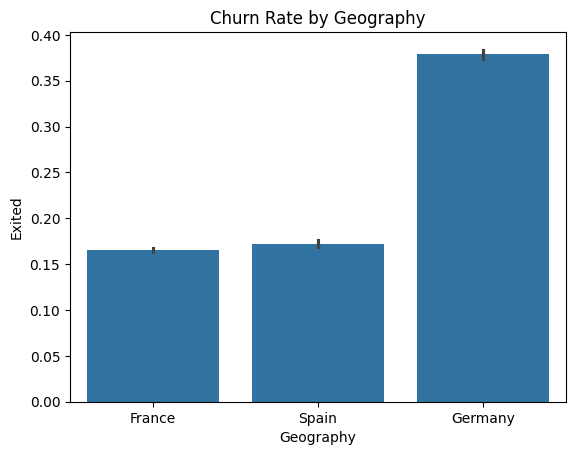

In [7]:
# Churn rate by geography
sns.barplot(data=df, x='Geography', y='Exited')
plt.title('Churn Rate by Geography')
plt.show()

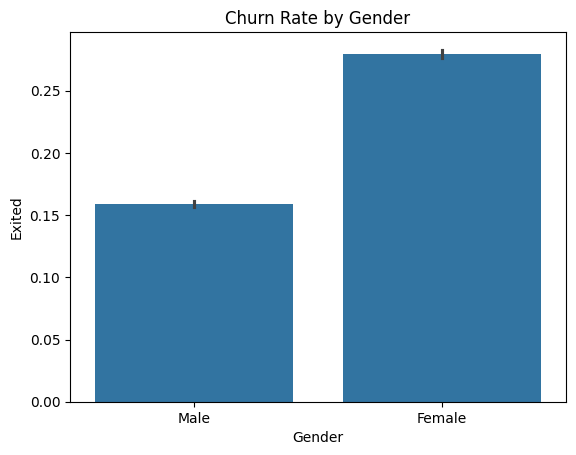

In [8]:
# Churn rate by gender
sns.barplot(data=df, x='Gender', y='Exited')
plt.title('Churn Rate by Gender')
plt.show()

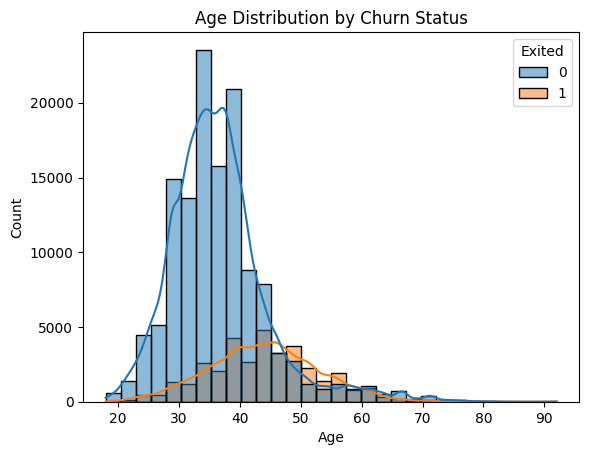

In [9]:
# Age distribution vs churn
sns.histplot(data=df, x='Age', hue='Exited', bins=30, kde=True)
plt.title('Age Distribution by Churn Status')
plt.show()

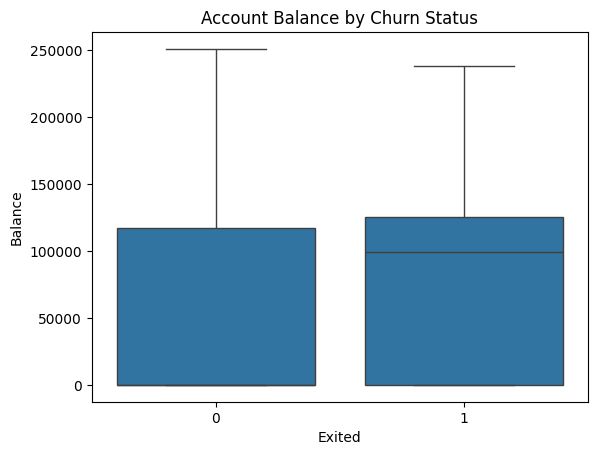

In [10]:
# Balance vs churn
sns.boxplot(data=df, x='Exited', y='Balance')
plt.title('Account Balance by Churn Status')
plt.show()

**Observations (fill in your own after running):**
- Note churn rate imbalance (~20% churned)
- Note which geography/gender shows higher churn
- Note age pattern (older customers tend to churn more in this dataset)

## 4. Feature Engineering

In [11]:
clean_df = df.copy()

# Drop identifier columns (not predictive)
clean_df.drop(['id', 'CustomerId', 'Surname'], axis=1, inplace=True)

# One-hot encode Gender
clean_df['Is_Male'] = clean_df['Gender'].apply(lambda x: 1 if x == 'Male' else 0)
clean_df['Is_Female'] = clean_df['Gender'].apply(lambda x: 1 if x == 'Female' else 0)

# One-hot encode Geography
clean_df['Is_Germany'] = clean_df['Geography'].apply(lambda x: 1 if x == 'Germany' else 0)
clean_df['Is_Spain'] = clean_df['Geography'].apply(lambda x: 1 if x == 'Spain' else 0)
clean_df['Is_France'] = clean_df['Geography'].apply(lambda x: 1 if x == 'France' else 0)

clean_df.drop(['Geography', 'Gender'], axis=1, inplace=True)
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165034 entries, 0 to 165033
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   CreditScore      165034 non-null  int64  
 1   Age              165034 non-null  float64
 2   Tenure           165034 non-null  int64  
 3   Balance          165034 non-null  float64
 4   NumOfProducts    165034 non-null  int64  
 5   HasCrCard        165034 non-null  float64
 6   IsActiveMember   165034 non-null  float64
 7   EstimatedSalary  165034 non-null  float64
 8   Exited           165034 non-null  int64  
 9   Is_Male          165034 non-null  int64  
 10  Is_Female        165034 non-null  int64  
 11  Is_Germany       165034 non-null  int64  
 12  Is_Spain         165034 non-null  int64  
 13  Is_France        165034 non-null  int64  
dtypes: float64(5), int64(9)
memory usage: 17.6 MB


## 5. Train/Test Split

In [12]:
X = clean_df.drop(columns='Exited')
y = clean_df['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])
print("Train churn rate:", y_train.mean(), "| Test churn rate:", y_test.mean())

Train size: 132027 | Test size: 33007
Train churn rate: 0.21160065744128095 | Test churn rate: 0.2115914805950253


In [13]:
# Scaled versions (needed for Random Forest / Neural Network)
scaler = StandardScaler()
X_scaler = scaler.fit(X_train)
X_train_scaled = X_scaler.transform(X_train)
X_test_scaled = X_scaler.transform(X_test)

## 6. Model 1 — Logistic Regression (baseline)

In [14]:
log_model = LogisticRegression(solver='lbfgs', max_iter=200, random_state=1)
log_model.fit(X_train, y_train)

log_preds = log_model.predict(X_test)
log_acc = accuracy_score(y_test, log_preds)
log_f1 = f1_score(y_test, log_preds)

print(f"Logistic Regression — Accuracy: {log_acc:.4f} | F1: {log_f1:.4f}")
print(classification_report(y_test, log_preds))

Logistic Regression — Accuracy: 0.8272 | F1: 0.4702
              precision    recall  f1-score   support

           0       0.85      0.95      0.90     26023
           1       0.67      0.36      0.47      6984

    accuracy                           0.83     33007
   macro avg       0.76      0.66      0.68     33007
weighted avg       0.81      0.83      0.81     33007



c:\Program Files\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 7. Model 2 — Random Forest

In [15]:
rf_model = RandomForestClassifier(n_estimators=500, random_state=78)
rf_model.fit(X_train_scaled, y_train)

rf_preds = rf_model.predict(X_test_scaled)
rf_acc = accuracy_score(y_test, rf_preds)
rf_f1 = f1_score(y_test, rf_preds)

print(f"Random Forest — Accuracy: {rf_acc:.4f} | F1: {rf_f1:.4f}")
print(classification_report(y_test, rf_preds))

Random Forest — Accuracy: 0.8581 | F1: 0.6150
              precision    recall  f1-score   support

           0       0.88      0.94      0.91     26023
           1       0.72      0.54      0.61      6984

    accuracy                           0.86     33007
   macro avg       0.80      0.74      0.76     33007
weighted avg       0.85      0.86      0.85     33007



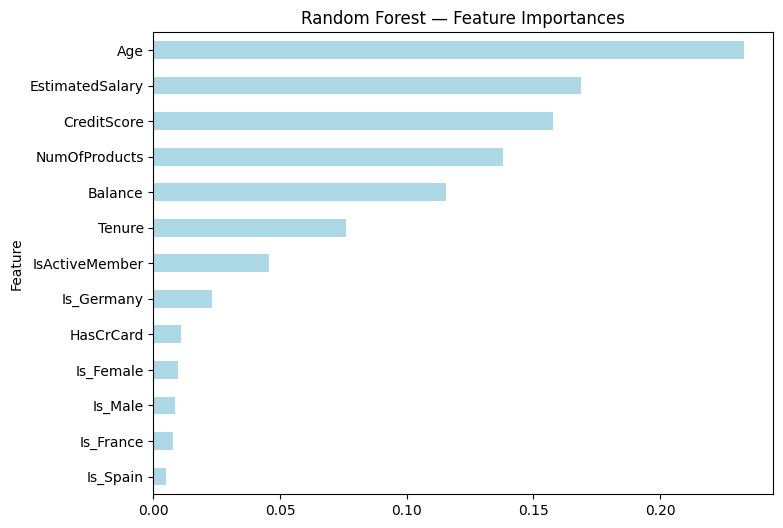

In [16]:
# Feature importance — Random Forest
rf_importances = pd.DataFrame(
    sorted(zip(rf_model.feature_importances_, X.columns), reverse=True),
    columns=['Importance', 'Feature']
).set_index('Feature').sort_values('Importance')

rf_importances.plot(kind='barh', color='lightblue', title='Random Forest — Feature Importances', legend=False, figsize=(8,6))
plt.show()

## 8. Model 3 — XGBoost (tuned)

In [17]:
# Manual params (skip full GridSearchCV to save time — these are sensible defaults)
xgb_model = XGBClassifier(learning_rate=0.1, max_depth=5, n_estimators=200, random_state=50)
xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_preds)
xgb_f1 = f1_score(y_test, xgb_preds)

print(f"XGBoost — Accuracy: {xgb_acc:.4f} | F1: {xgb_f1:.4f}")
print(classification_report(y_test, xgb_preds))

XGBoost — Accuracy: 0.8664 | F1: 0.6396
              precision    recall  f1-score   support

           0       0.89      0.95      0.92     26023
           1       0.75      0.56      0.64      6984

    accuracy                           0.87     33007
   macro avg       0.82      0.75      0.78     33007
weighted avg       0.86      0.87      0.86     33007



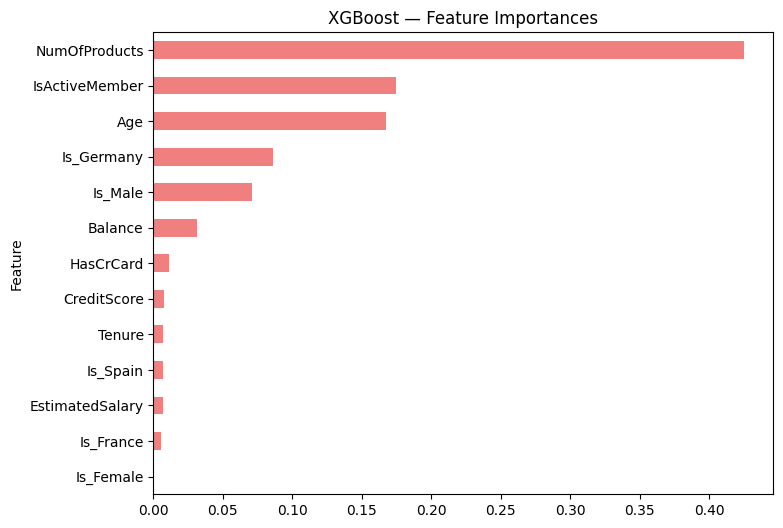

In [18]:
# Feature importance — XGBoost
xgb_importances = pd.DataFrame(
    sorted(zip(xgb_model.feature_importances_, X.columns), reverse=True),
    columns=['Importance', 'Feature']
).set_index('Feature').sort_values('Importance')

xgb_importances.plot(kind='barh', color='lightcoral', title='XGBoost — Feature Importances', legend=False, figsize=(8,6))
plt.show()

XGBoost ROC-AUC: 0.8897


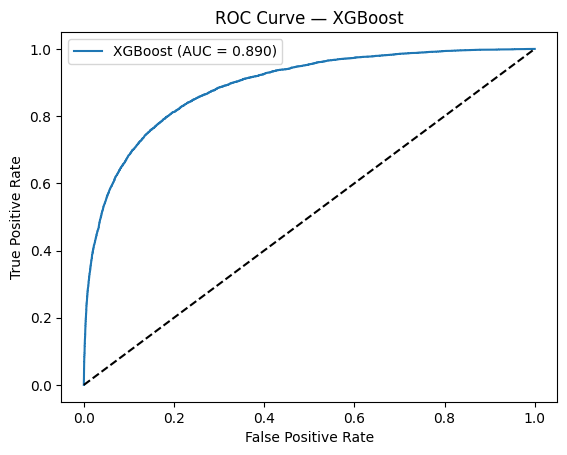

In [19]:
from sklearn.metrics import roc_auc_score, roc_curve

xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
xgb_auc = roc_auc_score(y_test, xgb_probs)
print(f"XGBoost ROC-AUC: {xgb_auc:.4f}")

fpr, tpr, _ = roc_curve(y_test, xgb_probs)
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {xgb_auc:.3f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — XGBoost')
plt.legend()
plt.show()

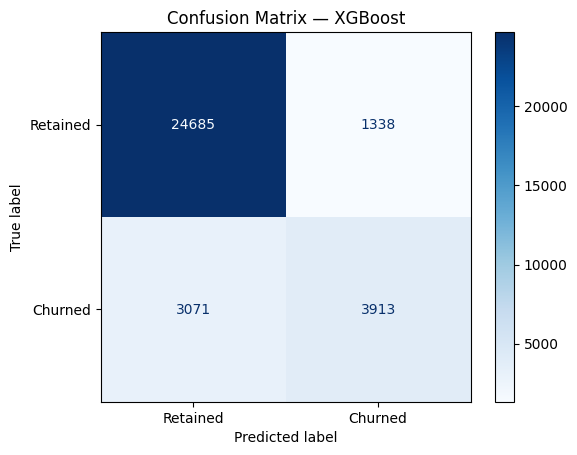

True Negatives: 24685 | False Positives: 1338
False Negatives: 3071 | True Positives: 3913


In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, xgb_preds)
ConfusionMatrixDisplay(cm, display_labels=['Retained','Churned']).plot(cmap='Blues')
plt.title('Confusion Matrix — XGBoost')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives: {tn} | False Positives: {fp}")
print(f"False Negatives: {fn} | True Positives: {tp}")

In [21]:
xgb_importances_sorted = xgb_importances.sort_values('Importance', ascending=False)
print(xgb_importances_sorted.head(10))

                Importance
Feature                   
NumOfProducts     0.424895
IsActiveMember    0.174883
Age               0.167594
Is_Germany        0.085931
Is_Male           0.071148
Balance           0.031190
HasCrCard         0.010874
CreditScore       0.007532
Tenure            0.007008
Is_Spain          0.006618


In [22]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
results = []
for t in thresholds:
    preds_t = (xgb_probs >= t).astype(int)
    results.append({
        'Threshold': t,
        'Precision': precision_score(y_test, preds_t),
        'Recall': recall_score(y_test, preds_t),
        'F1': f1_score(y_test, preds_t)
    })

pd.DataFrame(results)

,Threshold,Precision,Recall,F1
0,0.3,0.619913,0.713202,0.663293
1,0.4,0.688619,0.633305,0.659805
2,0.5,0.745191,0.560281,0.639640
3,0.6,0.792211,0.468929,0.589135
4,0.7,0.851756,0.378436,0.524041


## 9. Model 4 — Neural Network (Keras)

In [23]:
nn_model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(units=16, activation="relu", input_dim=X_train_scaled.shape[1]),
    tf.keras.layers.Dense(units=16, activation="relu"),
    tf.keras.layers.Dense(units=1, activation="sigmoid"),
])

nn_model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

history = nn_model.fit(X_train_scaled, y_train, epochs=50, verbose=0)

nn_loss, nn_acc = nn_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Neural Network — Loss: {nn_loss:.4f} | Accuracy: {nn_acc:.4f}")

c:\Program Files\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Neural Network — Loss: 0.3235 | Accuracy: 0.8646


In [24]:
nn_probs = nn_model.predict(X_test_scaled)
nn_preds = (nn_probs > 0.5).astype(int)
nn_f1 = f1_score(y_test, nn_preds)

print(classification_report(y_test, nn_preds))

1032/1032 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
              precision    recall  f1-score   support

           0       0.89      0.95      0.92     26023
           1       0.74      0.55      0.63      6984

    accuracy                           0.86     33007
   macro avg       0.82      0.75      0.77     33007
weighted avg       0.86      0.86      0.86     33007



## 10. Model Comparison

In [25]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'Neural Network'],
    'Accuracy': [log_acc, rf_acc, xgb_acc, nn_acc],
    'F1 Score': [log_f1, rf_f1, xgb_f1, nn_f1],
}).sort_values('F1 Score', ascending=False).reset_index(drop=True)

comparison

,Model,Accuracy,F1 Score
0,XGBoost,0.866422,0.639640
1,Neural Network,0.864635,0.632505
2,Random Forest,0.858091,0.614993
3,Logistic Regression,0.827218,0.470228


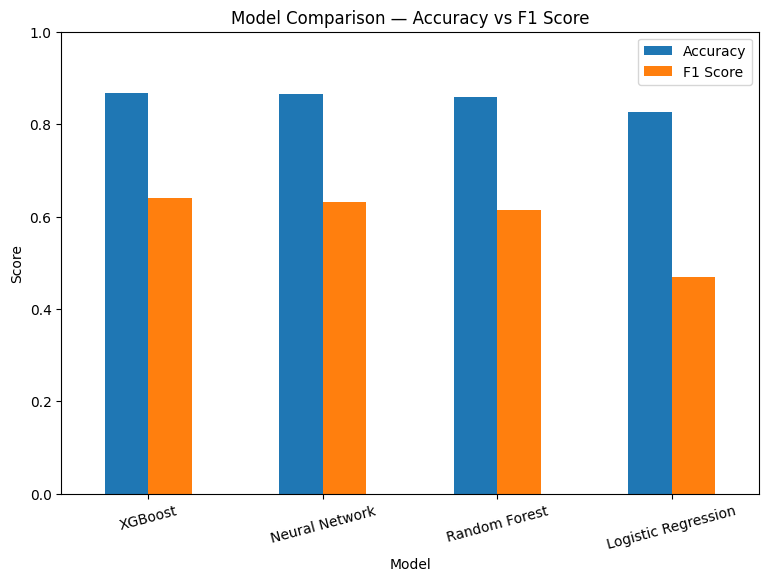

In [26]:
comparison.set_index('Model')[['Accuracy','F1 Score']].plot(kind='bar', figsize=(9,6))
plt.title('Model Comparison — Accuracy vs F1 Score')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.ylim(0,1)
plt.show()

## 11. Conclusion

*(Write your own conclusion after running — e.g. which model performed best, why, and what you'd try next: SHAP explainability, business-threshold tuning, deployment.)*

## 12. Save Best Model

In [27]:
# Example: save whichever model performed best
best_model_name = comparison.iloc[0]['Model']
print("Best model:", best_model_name)

# joblib.dump(xgb_model, 'best_model.pkl')  # uncomment and adjust based on winner

Best model: XGBoost
